📊 Overall R² Score: 0.8924 (1.0 is perfect)
📉 Mean Squared Error: 66751.94
📈 RMSE: 258.36


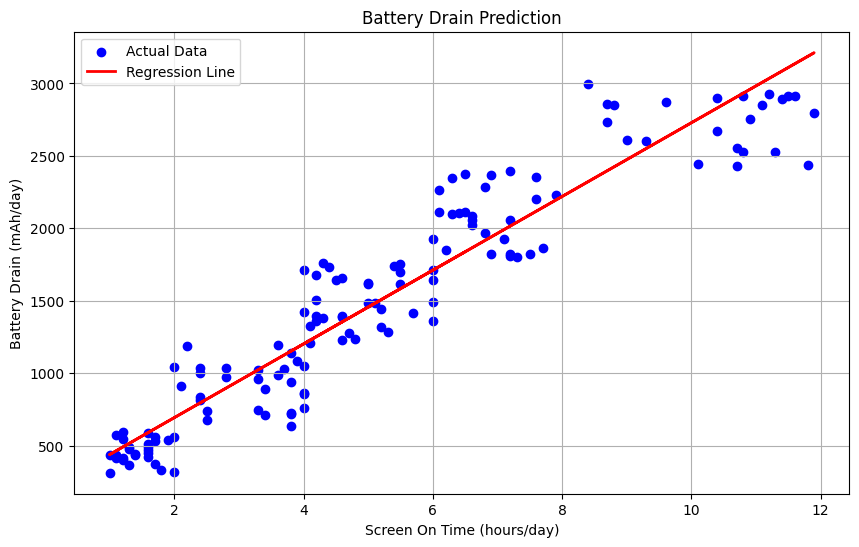


🔋 Prediction for 5.5 hours of Screen On Time:
Estimated Battery Drain: 1584 mAh/day


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Load Dataset
df = pd.read_csv("user_behavior_dataset.csv")   # change file name if needed

# Select Input and Output
X = df[['Screen On Time (hours/day)']]
y = df['Battery Drain (mAh/day)']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions on Test Data
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"📊 Overall R² Score: {r2:.4f} (1.0 is perfect)")
print(f"📉 Mean Squared Error: {mse:.2f}")
print(f"📈 RMSE: {rmse:.2f}")

# Graph
plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, color="blue", label="Actual Data")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Regression Line")

plt.title("Battery Drain Prediction")
plt.xlabel("Screen On Time (hours/day)")
plt.ylabel("Battery Drain (mAh/day)")
plt.legend()
plt.grid(True)
plt.show()

# Custom Prediction Function
def predict_battery_drain(hours):
    prediction = model.predict([[hours]])[0]
    print(f"\n🔋 Prediction for {hours} hours of Screen On Time:")
    print(f"Estimated Battery Drain: {prediction:.0f} mAh/day")

# Try it yourself!
try:
    user_input = float(input("Enter Screen On Time in hours (e.g., 5.5): "))
    predict_battery_drain(user_input)

except ValueError:
    print("❌ Invalid input! Please enter a number.")